# First steps with the new code
Lets try the new Trefftzmesh

In [1]:
from trefftz.mesh import TrefftzMesh

In [2]:
from enum import IntEnum, StrEnum



class WaveguideRegionsGMSH(IntEnum):
    OMEGA = 0
    GAMMA = 1
    SIGMA_L = 2
    SIGMA_R = 3


def CleanWaveguide_GMSH(H: float = 1., R: float = 5., lc: float = 0.3, verbose: bool = False) -> TrefftzMesh[WaveguideRegionsGMSH]:
    '''Creates a domain corresponging to a waveguide without scatterers.
    It assumes the default tags for the subregions, i.e.:
    - Omega = 0
    - Gamma = 1
    - Sigma = 2
    '''
    import gmsh


    gmsh.initialize()
    gmsh.option.setNumber("General.Terminal", int(verbose))
    gmsh.model.add("Waveguide")
    p0 = gmsh.model.geo.addPoint(-R, 0., 0., lc)
    p1 = gmsh.model.geo.addPoint( R, 0., 0., lc)
    p2 = gmsh.model.geo.addPoint( R,  H, 0., lc)
    p3 = gmsh.model.geo.addPoint(-R,  H, 0., lc)

    bottom = gmsh.model.geo.addLine(p0, p1)
    right  = gmsh.model.geo.addLine(p1, p2)
    top    = gmsh.model.geo.addLine(p2, p3)
    left   = gmsh.model.geo.addLine(p3, p0)

    boundary = gmsh.model.geo.addCurveLoop([bottom, right, top, left])
    domain = gmsh.model.geo.addPlaneSurface([boundary])
    gmsh.model.geo.synchronize()

    gmsh.model.addPhysicalGroup(2, [domain], WaveguideRegionsGMSH.OMEGA, "Omega")
    gmsh.model.addPhysicalGroup(1, [bottom, top], WaveguideRegionsGMSH.GAMMA, "Gamma")
    gmsh.model.addPhysicalGroup(1, [left], WaveguideRegionsGMSH.SIGMA_L, "Sigma_L")
    gmsh.model.addPhysicalGroup(1, [right], WaveguideRegionsGMSH.SIGMA_R, "Sigma_R")
    
    gmsh.model.geo.synchronize()
    gmsh.model.mesh.generate(2)
 
    mesh = TrefftzMesh.from_gmsh(gmsh.model, boundary_regions = WaveguideRegionsGMSH) #gmsh needs to be initialized for this to work
    
    gmsh.finalize()

    return mesh


class WaveguideRegionsNGSOLVE(StrEnum):
    OMEGA = "Omega"
    GAMMA = "Gamma"
    SIGMA_L = "Sigma_L"
    SIGMA_R = "Sigma_R"

def CleanWaveguide_NGSOLVE(H: float = 1., R: float = 5., lc: float = 0.3, verbosity: int = 0) -> TrefftzMesh[WaveguideRegionsNGSOLVE]:

    '''Creates a domain corresponging to a waveguide without scatterers.
    It assumes the default tags for the subregions, i.e.:
    - Omega = 0
    - Gamma = 1
    - Sigma = 2
    '''
    from netgen.geom2d import SplineGeometry
    from ngsolve import Mesh
    geo = SplineGeometry()
    p0 = geo.AddPoint(-R, 0.)
    p1 = geo.AddPoint( R, 0.)
    p2 = geo.AddPoint( R, H)
    p3 = geo.AddPoint(-R, H)
 
    bottom = geo.Append(["line", p0, p1], bc=WaveguideRegionsNGSOLVE.GAMMA)
    right  = geo.Append(["line", p1, p2], bc=WaveguideRegionsNGSOLVE.SIGMA_R)
    top    = geo.Append(["line", p2, p3], bc=WaveguideRegionsNGSOLVE.GAMMA)
    left   = geo.Append(["line", p3, p0], bc=WaveguideRegionsNGSOLVE.SIGMA_L)


    ngmesh = Mesh(geo.GenerateMesh(maxh=lc, perfstepsend=verbosity))

    
    mesh = TrefftzMesh.from_ngsolve(ngmesh, boundary_regions=WaveguideRegionsNGSOLVE)

    return mesh



In [52]:
R = 2.
H = 1. 

NGSOLVE = False

lc = 0.3

if NGSOLVE:
    mesh = CleanWaveguide_NGSOLVE(R=R, H=H, verbosity=0, lc=lc)
    WaveguideRegions = WaveguideRegionsNGSOLVE
else:
    mesh = CleanWaveguide_GMSH(R=R, H=H, verbose=True, lc=lc)
    WaveguideRegions = WaveguideRegionsGMSH


Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 30%] Meshing curve 2 (Line)
Info    : [ 60%] Meshing curve 3 (Line)
Info    : [ 80%] Meshing curve 4 (Line)
Info    : Done meshing 1D (Wall 0.000249405s, CPU 0.00271s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.00179898s, CPU 0s)
Info    : 81 nodes 164 elements


In [53]:
# from trefftz.mesh.checking_utilities import explore_edges
# import matplotlib
# matplotlib.use("TkAgg")
# print(matplotlib.get_backend())

In [54]:
# import matplotlib.pyplot as plt
# fig, ax = plt.subplots()

In [55]:
# explore_edges(mesh,figax=(fig, ax))

In [56]:
from problems.base2 import Problem

In [57]:
from trefftz.dg.basis import LinearlySpacedBasis

k = 8.0

basis = LinearlySpacedBasis(N_elements=mesh.n_triangles, k=k, N_theta=15)

In [58]:
from trefftz.dg.boundary_conditions2 import SoundHardBC, NtDBC

In [59]:
boundary_conditions = {WaveguideRegions.GAMMA: SoundHardBC(),
                       WaveguideRegions.SIGMA_L: NtDBC(truncating_radius=R, data=1.),
                       WaveguideRegions.SIGMA_R: NtDBC(truncating_radius=R, data=1.)}

In [60]:
from trefftz.dg.assemblers import SerialNumerics

In [61]:
from trefftz.dg.serial_kernels import SoundHardKernel, UltraWeakKernel, NtDLocal, WaveguideNtD_nonlocal

In [62]:
serial_numerics = SerialNumerics(interior_kernel=UltraWeakKernel(a=0.5, b=0.5),
                                 local_boundary_kernels={SoundHardBC: SoundHardKernel(d_1 = 0.5),
                                                         NtDBC: NtDLocal(R=R, d_2=0.5, H=H, n=2)},
                                 nonlocal_boundary_kernels={NtDBC: WaveguideNtD_nonlocal(R=R, d_2=0.5, M = 20, H = 1.)})

In [63]:
from trefftz.dg.assemblers import SerialAssembler

assembler = SerialAssembler(mesh,
                            boundary_conditions,
                            serial_numerics,
                            basis)

In [64]:
P = Problem(mesh=mesh, wavenumber=k, basis=basis, boundary_conditions=boundary_conditions, assembler=assembler, numerics=serial_numerics)

In [65]:
A = P.assemble_LHS()

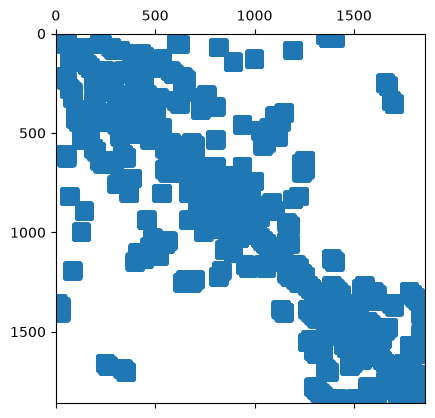

In [66]:
import matplotlib.pyplot as plt 
plt.spy(A)

In [67]:
b = P.assemble_RHS()

In [68]:
b is None

False

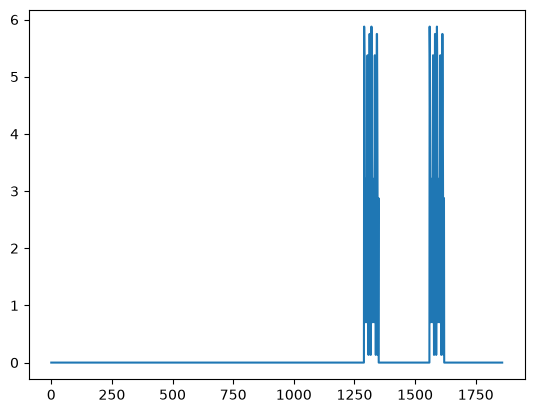

In [69]:
import numpy as np
plt.plot(np.abs(b))

In [70]:
P.solve()

In [71]:
P.u_h.coefficients.reshape((-1,3))

array([[ 3.30197667e+00   +5.73337603j, -4.26564465e+00   +5.25569554j,
        -1.46000554e+00   +6.8112367j ],
       [ 5.29821340e+00   +3.60402144j,  3.94340921e+00   -4.79302372j,
        -6.75295065e-01   -5.79464752j],
       [ 3.37166761e+00   -5.6797184j ,  1.05524403e+00   +6.60394066j,
         6.10343592e+00   -2.88303153j],
       ...,
       [ 2.95947105e+02  -80.09218799j,  2.02450066e+01 -185.95535381j,
        -5.25470497e+02 +190.38380559j],
       [ 2.63097538e+02 -893.77496067j,  2.49002590e+02-1227.92419642j,
        -1.49568740e+03 +142.89576062j],
       [ 1.62083471e+03 +419.62779756j, -1.35989199e+03-1130.85460465j,
        -1.09379322e+03+1418.29688845j]], shape=(620, 3))

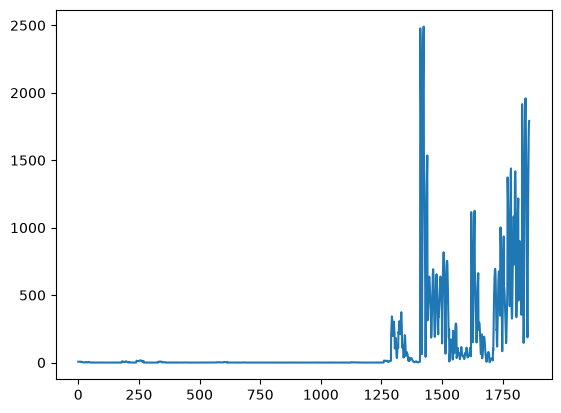

In [72]:
import numpy as np
plt.plot(np.abs(P.u_h.coefficients))

In [73]:
import numpy as np
N = 200
x = np.linspace(-R, R, N)
y = np.linspace(0., H, int(N*H/R))
X, Y = np.meshgrid(x, y)
Z = P.u_h(X.ravel(), Y.ravel()).reshape(X.shape)

(np.float64(-2.0100502512562812),
 np.float64(2.0100502512562812),
 np.float64(-0.005050505050505051),
 np.float64(1.005050505050505))

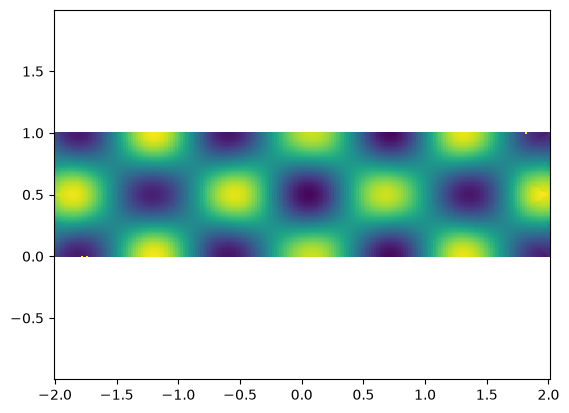

In [77]:
import matplotlib.pyplot as plt 
plt.pcolormesh(X, Y, Z.real, vmin=-3, vmax=3)
plt.axis('equal')